# Visualization

## Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import ast
import seaborn as sns
import json
import glob
import random
from copy import deepcopy
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, to_rgb, to_rgba

import tensorflow as tf
from Fitting_algo_v4 import *
from ECM_impedance_v3 import *

Load Battery Metadata:

In [78]:
battery_json_file = "../EVC_EIS_Data/original_data/Battery_Info_DRT.json" # Check the path

with open(battery_json_file, "r") as f:
    BATTER_METADATA = json.load(f)   # <--- this is now a dict
# Review current documented batteries
print(BATTER_METADATA.keys())

dict_keys(['CELL009', 'CELL021', 'CELL077', 'CELL013', 'CELL042', 'CELL045', 'CELL050', 'CELL054', 'CELL076', 'CELL090', 'CELL096', 'CELL032', 'CELL070', 'CELL101'])


Load Battery EIS data:

In [80]:
def format_EIS(input_file):
    """
    Load EIS input csv and return a list of dictionary indexed by soc_index.

    Parameters
    ----------
    input_file : str
        csv file path of original EIS data, required to have columns ['time/s', 'I/mA', 'Ewe/V', 'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle'].
    
    Returns
    ----------
    grouped_list : [{soc_dict}], a list of SOC dictionaries. soc_dict has attributes: freq, angular_freq, Z_mag, phase_deg, Z_real, Z_imag.
    """
    df = pd.read_csv(input_file)

    # Ensure relevant columns exist
    required = ['time/s', 'I/mA', 'Ewe/V', 'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Ensure numeric
    num_cols = ['time/s', 'I/mA', 'Ewe/V', 'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle']
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    # Keep relevant cols and drop invalid rows
    df = (
        df[['freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle']]
        .dropna(subset=['freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle'])
        .query("`freq/Hz` != 0")
        .copy()
    )

    # Compute Z components
    phase_rad = np.deg2rad(df['Phase(Z)/deg'].to_numpy())
    Z_mag = df['|Z|/Ohm'].to_numpy()
    df['Z_mag'] = Z_mag
    df['Z_real'] = Z_mag * np.cos(phase_rad)
    df['Z_imag'] = Z_mag * np.sin(phase_rad)
    df['angular_freq'] = 2 * np.pi * df['freq/Hz'].to_numpy()
    df['soc_index'] = df['z cycle'].astype(int)

    # Group by z cycle and build list (index = soc_index)
    grouped_list = []
    for _, g in df.groupby('z cycle'):
        g_sorted = g.sort_values('freq/Hz', ascending=False)
        grouped_list.append({
            "freq": g_sorted['freq/Hz'].to_numpy(dtype=float),
            "angular_freq": g_sorted['angular_freq'].to_numpy(dtype=float),
            "Z_mag": g_sorted['Z_mag'].to_numpy(dtype=float),
            "phase_deg": g_sorted['Phase(Z)/deg'].to_numpy(dtype=float),
            "Z_real": g_sorted['Z_real'].to_numpy(dtype=float),
            "Z_imag": g_sorted['Z_imag'].to_numpy(dtype=float),
        })

    return grouped_list

In [82]:
# Load EIS data
BATTERY_EISDATA = {}
for cell in BATTER_METADATA.keys():
    celli_metadata = BATTER_METADATA[cell]
    print(f"====== Loading EIS data for {cell}, temp={celli_metadata["temperature"]}, num_soh={celli_metadata["num_soh"]} =====")

    # Battery data retrieval
    for i in range(celli_metadata["num_soh"]):
        # Access SOH data
        soh_data = celli_metadata["soh"][i]
        print(f"SOH idex {i+1}, EIS data file: {soh_data["file"]}, Charge Capacity is {soh_data["capacity"]}")
        # Access SOC data
        print(f"---- This SOH state has {soh_data["num_soc"]} soc data: {soh_data["soc"]}")


    # Build EIS dictionary
    relative_path_to_data_dir = "../EVC_EIS_Data/original_data/" # Change to match data dir
    celli_EISdata = [] # list indexed by soh


    for i in range(celli_metadata["num_soh"]):
        soh_data = celli_metadata["soh"][i]
        EIS_filename = os.path.join(relative_path_to_data_dir, soh_data["file"])
        print(f"Loading file from {EIS_filename}")
        soh_dic = format_EIS(EIS_filename)
        celli_EISdata.append(soh_dic)
    
    BATTERY_EISDATA[cell] = celli_EISdata
    print(f"Finished.")
    

====== Loading EIS data for CELL009, temp=0, num_soh=4 =====
SOH idex 1, EIS data file: CELL009/ConvertFromMPR/GMJuly2022_CELL009_BOL_Characterization_R1_01_MB_CA6.csv, Charge Capacity is 3.58344999999088
---- This SOH state has 11 soc data: [0.915987837068381, 0.832495084994038, 0.748993864639892, 0.665491401570284, 0.582018296872806, 0.498495690345182, 0.414917580904707, 0.331370965171493, 0.247849014307924, 0.164266613065507, 0.0807002490578597]
SOH idex 2, EIS data file: CELL009/ConvertFromMPR/GMJuly2022_CELL009_EOLeis_2_P25C_15P0PSI_20230329_R0_CA1.csv, Charge Capacity is 2.23921999999413
---- This SOH state has 13 soc data: [0.936080033489535, 0.872124862270506, 0.808323435539052, 0.744363267339881, 0.680418786620041, 0.616507880933721, 0.552586984865072, 0.488689806902847, 0.424730693463131, 0.360836771505811, 0.296944550193152, 0.23298683475855, 0.169017110070977]
SOH idex 3, EIS data file: CELL009/ConvertFromMPR/GMJuly2022_CELL009_EIS_3d_P25C_15P0PSI_20230424_R0_CA3.csv, Charg

Load DRT Data:

In [ ]:
# CELL_TEMPDATA = {
#     "CELL009": {"temperature": 0}, # SOC 0-100
#     "CELL021": {"temperature": 0}, # SOC 0-100
#     "CELL077": {"temperature": 0}, # SOC 0-100

#     "CELL013": {"temperature": 25}, # SOC 50-100
#     "CELL042": {"temperature": 25}, # SOC 0-100
#     "CELL045": {"temperature": 25}, # SOC 20-80
#     "CELL050": {"temperature": 25}, # SOC 0-100
#     "CELL054": {"temperature": 25}, # SOC 50-100
#     "CELL076": {"temperature": 25}, # SOC 20-80
#     "CELL090": {"temperature": 25}, # SOC 0-100
#     "CELL096": {"temperature": 25}, # SOC 50-100

#     "CELL032": {"temperature": 45}, # SOC 0-100
#     "CELL070": {"temperature": 45}, # SOC 0-100
#     "CELL101": {"temperature": 45}, # SOC 0-100
# }

# def read_drt_data(data_dir, features, target):
#     data_list = []
#     for cell in CELL_TEMPDATA.keys():
#         file_path = os.path.join(data_dir, f"data_{cell}.csv")
#         if os.path.exists(file_path):
#             df = pd.read_csv(file_path).dropna(how="all") # Drop all NA rows (in case)
#             # df = df[df["soc"] > 0.25] #NOTE: filter and keep soc > 0.25 only
#             df["Cell"] = cell
#             df["temperature"] = CELL_TEMPDATA[cell]["temperature"]
#             if "temperature" in features:
#                 data_list.append(df[features + [target, "Cell"]])
#             else:
#                 data_list.append(df[features + [target, "Cell", "temperature"]])
#         else:
#             print(f"Warning: file not found for {cell}")

#     data_all = pd.concat(data_list, ignore_index=True)
#     print(f"Total samples: {len(data_all)}")
#     return data_all

In [ ]:
# DATA_DIR = "../EVC_EIS_Data/CELL_DRT_Data" # Relative Path
# FEATURES = ["R0", "R1", "R2", "R3"]
# TARGET = "Charge_capacity_Ah"

# data_all = read_drt_data(DATA_DIR, FEATURES, TARGET)

## ECM Fitting Result

Functions:

In [2]:
ECM_candidates_map = dict(zip(ECM_NAMES, ECM_IMPEDANCE_FUNCS))

def EIS_Nyquist_meas_vs_fit(battery_name, battery_metadata, battery_EISdata, soh_label, soc_label, ECM_name, est_result_file, select_est_ranks=[1], subtitle="", show_legend=True):

    soh_soc_eis = battery_EISdata[soh_label-1][soc_label-1]

    Z_meas_real = soh_soc_eis["Z_real"]
    Z_meas_negimag = -soh_soc_eis["Z_imag"]
    angular_freq = soh_soc_eis["angular_freq"]
    
    if os.path.exists(est_result_file):
        df = pd.read_csv(est_result_file)
        selected = df[df["trial_rank"].isin(select_est_ranks)].copy()
    else:
        print(f"[WARN] est_result_file not found: {est_result_file}")
    
    plt.figure(figsize=(8,8))
    plt.plot(Z_meas_real, Z_meas_negimag, marker="o", label="Lab Measurement")

    for _, row in selected.iterrows():
            rank = int(row["trial_rank"])

            est_params = ast.literal_eval(row["estimated_params"])
            Z_fit = ECM_candidates_map[ECM_name](est_params, angular_freq)
            plt.plot(Z_fit.real, -Z_fit.imag, linestyle="--", marker="*", label=f"ECM fit (rank={rank})")

    plt.xlabel("Re(Z) [Ω]")
    plt.ylabel("-Im(Z) [Ω]")
    if show_legend:
        plt.legend()

    cap = battery_metadata["soh"][soh_label - 1]["capacity"]
    soc_val = battery_metadata["soh"][soh_label - 1]["soc"][soc_label - 1] * 100.0
    plt.title(
        f"{battery_name} Lab EIS vs ECM Reconstruction\n"
        f"SOH_index = {soh_label}; Capacity = {cap:.2f}\n"
        f"SOC_index = {soc_label}; SOC = {soc_val:.2f}%\n"
        f"{subtitle}"
    )

    plt.tight_layout()
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.show()

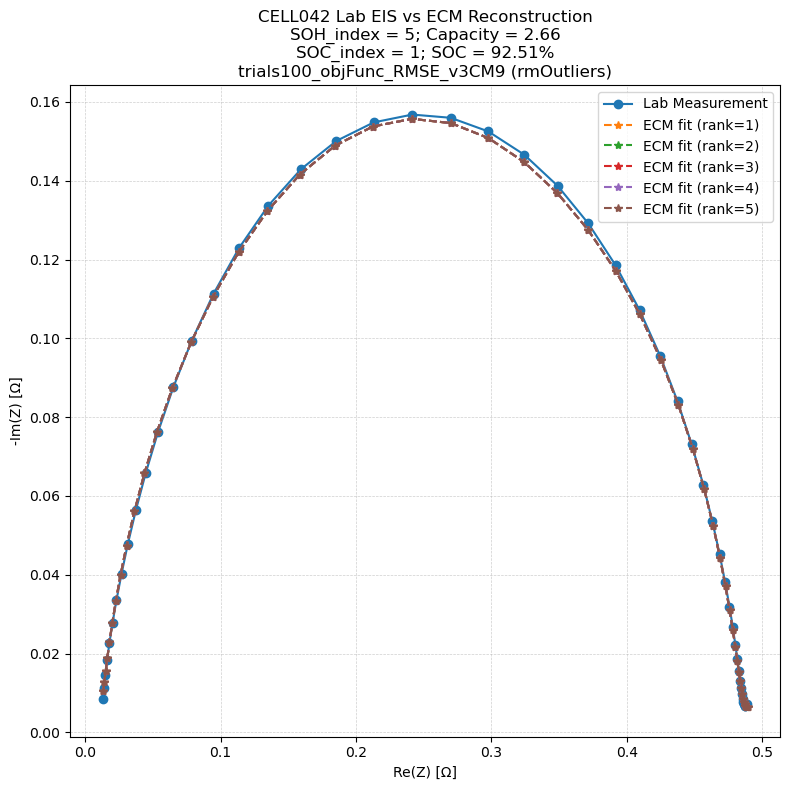

In [ ]:
CELL_NAME = "CELL042"
soh_label = 5
soc_label = 1
ECM_name = "v3CM9"
obj_func = "RMSE"
num_trials = 100

# ======================================================================== #
celli_metadata = BATTER_METADATA[CELL_NAME]
celli_EISdata = BATTERY_EISDATA[CELL_NAME]

filepath = f"ECM_Params_Estimation/{CELL_NAME}/{ECM_name}_{obj_func}_trials{num_trials}/soh{soh_label}/{CELL_NAME}_soh{soh_label}_soc{soc_label}_trials{num_trials}_objFunc_{obj_func}_{ECM_name}_rmOutliers.csv"
subtitle = f"trials{num_trials}_objFunc_{obj_func}_{ECM_name} (rmOutliers)"

df = pd.read_csv(filepath)
select_ranks = df["trial_rank"].values
select_ranks = [1,2,3,4,5]

EIS_Nyquist_meas_vs_fit(CELL_NAME, celli_metadata, celli_EISdata, soh_label, soc_label, ECM_name, filepath, select_est_ranks=select_ranks, subtitle=subtitle)

## BOL & EOL boxplots -- per-parameter v.s SOC

functions:

In [45]:
def plot_param_boxplots(cell_name, bol_info, eol_info, param_name, num_trials=100, objFunc="RMSE", ECM_name="v3CM9"):
    """
    Create boxplots comparing BOL and EOL parameter distributions across SOC values.

    Parameters:
        cell_name (str): e.g., "C10"
        bol_info (list of tuples): [(soh_idx, [soc1, soc2, ...])]
        eol_info (list of tuples): [(soh_idx, [soc1, soc2, ...])]
        param_name (str): e.g., "R3"
    """
    data = []
    # Helper to read CSVs
    def collect_data(soh_type, info_list):
        for soh_label, soc_list in info_list:
            for soc_idx in range(len(soc_list)):
                file_name = f"ECM_Params_Estimation/{cell_name}/{ECM_name}_{objFunc}_trials{num_trials}/soh{soh_label}/{cell_name}_soh{soh_label}_soc{soc_idx+1}_trials{num_trials}_objFunc_{objFunc}_{ECM_name}_rmOutliers.csv"
                if not os.path.exists(file_name):
                    print(f"[Warning] Missing file: {file_name}")
                    continue
                df = pd.read_csv(file_name)
                df["SOH"] = soh_type
                df["SOC"] = round(soc_list[soc_idx] * 100, 2)
                data.append(df[["SOH", "SOC", param_name]])

    collect_data("BOL", bol_info)
    collect_data("EOL", eol_info)

    all_data = pd.concat(data, ignore_index=True)

    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(
        data=all_data,
        x="SOC",
        y=param_name,
        hue="SOH",
        palette={"BOL": "skyblue", "EOL": "lightcoral"},
        showfliers=True
    )

    for i, artist in enumerate(ax.artists):
        if i % 2 == 0:  # BOL
            artist.set_edgecolor("blue")
        else:            # EOL
            artist.set_edgecolor("red")
        artist.set_linewidth(1.5)

    # ---- Compute medians for overlay ----
    median_data = all_data.groupby(["SOH", "SOC"], as_index=False)[param_name].median()

    # ---- Overlay median line ----
    sns.lineplot(
        data=median_data[median_data["SOH"] == "BOL"],
        x="SOC", y=param_name,
        color="blue", marker="o", markersize=6,
        linewidth=2.2, label="BOL Median", ax=ax
    )
    sns.lineplot(
        data=median_data[median_data["SOH"] == "EOL"],
        x="SOC", y=param_name,
        color="red", marker="o", markersize=6,
        linewidth=2.2, label="EOL Median", ax=ax
    )

    # ---- Labels and layout ----
    plt.title(f"{cell_name} BOL & EOL {param_name} vs SOC\n{ECM_name}_trials{num_trials}_rmOutliers")
    plt.xlabel("SOC (%)")
    plt.ylabel(param_name)
    plt.gca().invert_xaxis()
    plt.legend(title="SOH", loc="upper right")
    plt.tight_layout()
    plt.show()


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

def plot_param_boxplots(cell_name, bol_info, eol_info, param_name, num_trials=100, objFunc="RMSE", ECM_name="v3CM9"):
    """
    Create boxplots comparing BOL and EOL parameter distributions across SOC values,
    with median points overlaid.
    """
    data = []

    # ---- Helper to read CSVs ----
    def collect_data(soh_type, info_list):
        for soh_label, soc_list in info_list:
            for soc_idx in range(len(soc_list)):
                file_name = f"ECM_Params_Estimation/{cell_name}/{ECM_name}_{objFunc}_trials{num_trials}/soh{soh_label}/{cell_name}_soh{soh_label}_soc{soc_idx+1}_trials{num_trials}_objFunc_{objFunc}_{ECM_name}_rmOutliers.csv"
                if not os.path.exists(file_name):
                    print(f"⚠️ Missing file: {file_name}")
                    continue
                df = pd.read_csv(file_name)
                df["SOH"] = soh_type
                df["SOC"] = round(soc_list[soc_idx] * 100, 2)
                data.append(df[["SOH", "SOC", param_name]])

    collect_data("BOL", bol_info)
    collect_data("EOL", eol_info)

    all_data = pd.concat(data, ignore_index=True)

    # ---- Draw boxplot ----
    plt.figure(figsize=(14, 6))
    ax = sns.boxplot(
        data=all_data,
        x="SOC",
        y=param_name,
        hue="SOH",
        palette={"BOL": "skyblue", "EOL": "lightcoral"},
        showfliers=True,
        width=0.6
    )

    # ---- Customize box borders ----
    for i, artist in enumerate(ax.artists):
        edge_color = "blue" if i % 2 == 0 else "red"
        artist.set_edgecolor(edge_color)
        artist.set_linewidth(1.8)
        # recolor whiskers, caps, medians
        for j in range(i * 6, i * 6 + 6):
            line = ax.lines[j]
            line.set_color(edge_color)
            line.set_mfc(edge_color)
            line.set_mec(edge_color)

    # ---- Compute medians ----
    median_data = all_data.groupby(["SOH", "SOC"], as_index=False)[param_name].median()

    # Prepare for alignment
    soc_unique = np.sort(all_data["SOC"].unique())
    positions = np.arange(len(soc_unique))
    offset = 0  # horizontal offset for hue separation

    # ---- Plot median points only ----
    for soh, color, dx, marker in zip(["BOL", "EOL"], ["blue", "red"], [-offset, offset], ["o", "o"]):
        sub = median_data[median_data["SOH"] == soh]
        xvals = [positions[np.where(soc_unique == s)[0][0]] + dx for s in sub["SOC"]]
        ax.scatter(xvals, sub[param_name], color=color, s=60, marker=marker, edgecolors="black", linewidths=1.0, zorder=5, label=f"{soh} Median")

    # ---- Adjust ticks ----
    ax.set_xticks(positions)
    ax.set_xticklabels([f"{s:.2f}" for s in soc_unique])
    ax.invert_xaxis()

    # ---- Title and layout ----
    plt.title(f"{cell_name} BOL & EOL \n{param_name} vs SOC\n{ECM_name}_trials{num_trials}_rmOutliers")
    plt.xlabel("SOC (%)")
    plt.ylabel(param_name)
    plt.legend(title="SOH", loc="best")
    plt.tight_layout()
    plt.grid(True, linestyle='--', color='lightgray', linewidth=0.7, alpha=0.8)
    plt.show()


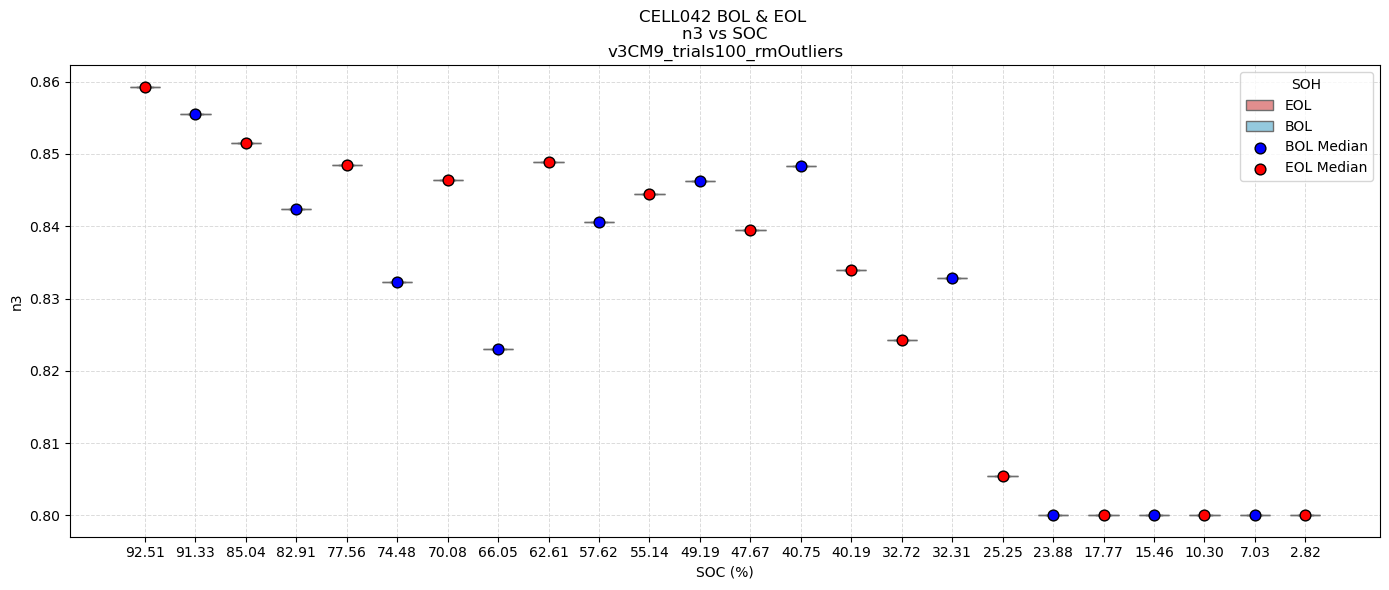

In [83]:
CELL_NAME = "CELL042"
BOL_soh_label = 1
EOL_soh_label = 5
ECM_name = "v3CM9"
obj_func = "RMSE"
num_trials = 100
param_name = "n3"

# ======================================================================== #
BOL_soc_list = BATTER_METADATA[CELL_NAME]["soh"][BOL_soh_label-1]["soc"]
EOL_soc_list = BATTER_METADATA[CELL_NAME]["soh"][EOL_soh_label-1]["soc"]
bol_info = [(BOL_soh_label, BOL_soc_list)]
eol_info = [(EOL_soh_label, EOL_soc_list)]

plot_param_boxplots(CELL_NAME, bol_info, eol_info, param_name)

## BOL & EOL Line Plot -- per-parameter v.s SOC

Functions:

In [107]:
import pandas as pd
import numpy as np
import os

def process_drt_data(cell_name, bol_date, eol_date):
    """
    Process DRT data for a given cell and extract rows for BOL and EOL dates.

    Parameters:
        cell_name (str): e.g., "CELL042"
        bol_date (str): Target BOL date in the CSV (e.g. '20240115')
        eol_date (str): Target EOL date in the CSV (e.g. '20240922')

    Returns:
        dict: {"BOL": <DataFrame>, "EOL": <DataFrame>} filtered and processed by date.
              Includes only ['date', 'soc', 'R1'...'Rn', 'freq1', 'freq2', 'freq3']
    """

    drt_csv = f"../EVC_EIS_Data/CELL_DRT_Data/data_{cell_name}.csv"
    if not os.path.exists(drt_csv):
        print(f"Warning: File not found: {drt_csv}")
        return {"BOL": pd.DataFrame(), "EOL": pd.DataFrame()}

    # Read and clean
    df = pd.read_csv(drt_csv)
    df.columns = df.columns.str.strip()
    df["date"] = df["date"].astype(str).str.strip()

    # Select relevant columns (R1...Rn + ln_1_over_freq1–3)
    r_cols = [col for col in df.columns if col.startswith("R")]
    freq_cols = [f"ln_1_over_freq{i}" for i in range(1, 4)]
    keep_cols = ["date", "soc"] + r_cols + freq_cols
    df = df[keep_cols]

    # Convert ln_1_over_freq → freq = exp(-ln_1_over_freq)
    for i in range(1, 4):
        df[f"freq{i}"] = np.exp(-df[f"ln_1_over_freq{i}"])

    # Drop original ln_1_over_freq columns
    df.drop(columns=freq_cols, inplace=True)

    # Filter by dates
    bol_df = df[df["date"] == bol_date].copy()
    eol_df = df[df["date"] == eol_date].copy()

    if bol_df.empty:
        print(f"Warning: No matching BOL data found for {bol_date} in {drt_csv}")
    if eol_df.empty:
        print(f"Warning: No matching EOL data found for {eol_date} in {drt_csv}")

    return {"BOL": bol_df, "EOL": eol_df}


In [108]:
def plot_param_summary_with_drt(cell_name, bol_info, eol_info, param_name, drt_data, num_trials=100, objFunc="RMSE", ECM_name="v3CM9"):
    """
    Create a line plot showing q1, median, q3, max, mean, and DRT value
    across concatenated SOC indices (BOL ↓ then EOL ↓).

    Parameters:
        drt_data (dict): Output from process_drt_data() — contains "BOL" and "EOL" DataFrames.
    """
    def collect_stats(soh_label, soc_list):
        stats = []
        for soc_idx, soc in enumerate(soc_list):
            file_name = (
                f"ECM_Params_Estimation/{cell_name}/"
                f"{ECM_name}_{objFunc}_trials{num_trials}/soh{soh_label}/"
                f"{cell_name}_soh{soh_label}_soc{soc_idx+1}_trials{num_trials}_"
                f"objFunc_{objFunc}_{ECM_name}_rmOutliers.csv"
            )
            if not os.path.exists(file_name):
                print(f"Warning: Missing file: {file_name}")
                continue

            df = pd.read_csv(file_name)
            values = df[param_name].dropna()
            stats.append({
                "soc": round(soc * 100, 2),
                "q1": np.percentile(values, 25),
                "median": np.median(values),
                "q3": np.percentile(values, 75),
                "max": np.max(values),
                "mean": np.mean(values)
            })
        return pd.DataFrame(stats)

    # Collect parameter statistics
    data_frames = []
    for soh_type, info_list in zip(["BOL", "EOL"], [bol_info, eol_info]):
        for soh_label, soc_list in info_list:
            df = collect_stats(soh_label, soc_list)
            df["SOH"] = soh_type
            data_frames.append(df)

    all_stats = pd.concat(data_frames, ignore_index=True)
    all_stats["index"] = np.arange(1, len(all_stats) + 1)

    # Merge DRT values
    drt_values = pd.concat([drt_data["BOL"][param_name], drt_data["EOL"][param_name]], ignore_index=True)
    all_stats["drt_value"] = drt_values.values[:len(all_stats)]

    # Plot
    plt.figure(figsize=(9, 5))
    plt.plot(all_stats["index"], all_stats["q1"], "-o", label="q1")
    plt.plot(all_stats["index"], all_stats["median"], "-o", label="median")
    plt.plot(all_stats["index"], all_stats["q3"], "-o", label="q3")
    plt.plot(all_stats["index"], all_stats["max"], "-o", label="max")
    plt.plot(all_stats["index"], all_stats["mean"], "-o", label="mean")
    plt.plot(all_stats["index"], all_stats["drt_value"], "-o", linewidth=2.2, label="DRT value")

    num_bol = len(bol_info[0][1])  # number of SOCs in BOL
    num_eol = len(eol_info[0][1])  # number of SOCs in EOL
    plt.title(f"{cell_name} BOL & EOL \n {param_name} Summary \n (BOL SOCs: {num_bol}, EOL SOCs: {num_eol})")
    plt.xlabel("SOC Index (BOL ↓ then EOL ↓)")
    plt.ylabel(param_name)
    plt.legend(title="Metric", loc="best")
    plt.grid(True, linestyle="--", color="lightgray", linewidth=0.7, alpha=0.8)
    plt.tight_layout()
    plt.xticks(np.arange(all_stats["index"].min(), all_stats["index"].max() + 1, 1))
    plt.show()


In [118]:
def print_freq_comparison(cell_name, soh_idx, soc_idx, date, ECM_name="v3CM9", objFunc="RMSE", num_trials=100):
    """
    Print ECM and DRT frequency (freq1–freq3) values for a given cell, SOH index, SOC index, and date.

    Parameters:
        cell_name (str): e.g., "CELL042"
        soh_idx (int): SOH index (e.g. 1 for BOL, 2 for EOL)
        soc_idx (int): SOC index (1-based)
        date (str): Date in DRT CSV (e.g. '20220916' or '20231011')
        ECM_name (str): ECM model name (default: 'v3CM9')
        objFunc (str): Objective function (default: 'RMSE')
        num_trials (int): Number of ECM estimation trials (default: 100)
    """

    # === ECM frequency ===
    ecm_file = f"ECM_Params_Estimation/{cell_name}/{ECM_name}_{objFunc}_trials{num_trials}/soh{soh_idx}/{cell_name}_soh{soh_idx}_soc{soc_idx}_trials{num_trials}_objFunc_{objFunc}_{ECM_name}_rmOutliers.csv"

    if not os.path.exists(ecm_file):
        print(f"Warning: ECM file not found:\n  {ecm_file}")
        ecm_freqs = None
    else:
        df_ecm = pd.read_csv(ecm_file)
        # Take mean of 100 trials for stable estimate
        ecm_freqs = df_ecm[['freq1', 'freq2', 'freq3']].mean().round(3).to_dict()

    # === DRT frequency ===
    drt_csv = f"../EVC_EIS_Data/CELL_DRT_Data/data_{cell_name}.csv"
    if not os.path.exists(drt_csv):
        print(f"Warning: DRT file not found:\n  {drt_csv}")
        drt_freqs = None
    else:
        df_drt = pd.read_csv(drt_csv)
        df_drt.columns = df_drt.columns.str.strip()
        df_drt["date"] = df_drt["date"].astype(str).str.strip()

        # Filter by date
        drt_date_df = df_drt[df_drt["date"] == date].copy()
        if drt_date_df.empty:
            print(f"Warning: No matching DRT data found for date {date}")
            drt_freqs = None
        else:
            # Convert ln_1_over_freq → freq
            for i in range(1, 4):
                drt_date_df[f"freq{i}"] = np.exp(-drt_date_df[f"ln_1_over_freq{i}"])
            try:
                drt_freqs = drt_date_df.iloc[soc_idx - 1][["freq1", "freq2", "freq3"]].round(3).to_dict()
            except IndexError:
                print(f"⚠️ Invalid SOC index {soc_idx} for DRT data on {date}")
                drt_freqs = None

    # === Print results ===
    print(f"\n Frequency comparison for {cell_name} | SOH {soh_idx} | SOC {soc_idx} | Date {date}")
    print("-" * 70)
    if ecm_freqs:
        print(f"ECM ({ECM_name}): freq1={ecm_freqs['freq1']}, freq2={ecm_freqs['freq2']}, freq3={ecm_freqs['freq3']}")
    else:
        print("ECM data not available.")
    if drt_freqs:
        print(f"DRT ({date}): freq1={drt_freqs['freq1']}, freq2={drt_freqs['freq2']}, freq3={drt_freqs['freq3']}")
    else:
        print("DRT data not available.")

Plot Usage:

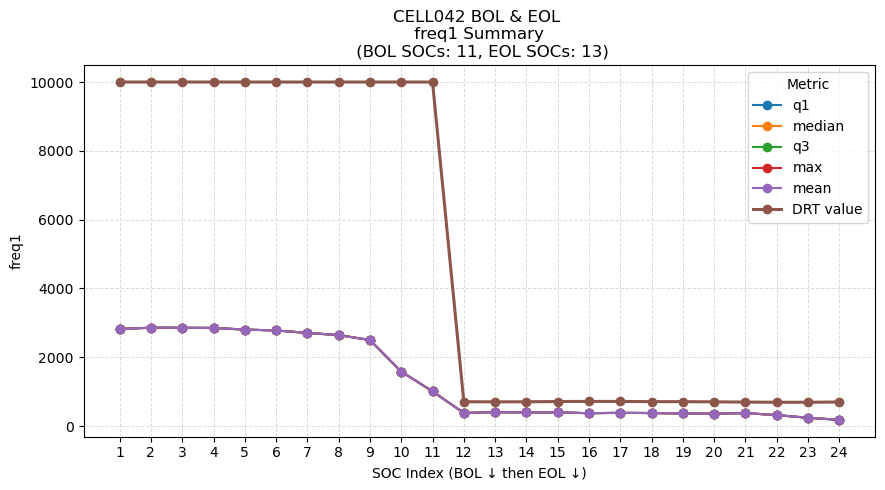

In [115]:
CELL_NAME = "CELL042"
BOL_soh_label = 1
EOL_soh_label = 5
ECM_name = "v3CM9"
obj_func = "RMSE"
num_trials = 100
param_name = "freq1"

# ======================================================================== #
BOL_date = BATTER_METADATA[CELL_NAME]["soh"][BOL_soh_label-1]["date"]
EOL_date = BATTER_METADATA[CELL_NAME]["soh"][EOL_soh_label-1]["date"]
BOL_soc_list = BATTER_METADATA[CELL_NAME]["soh"][BOL_soh_label-1]["soc"]
EOL_soc_list = BATTER_METADATA[CELL_NAME]["soh"][EOL_soh_label-1]["soc"]
bol_info = [(BOL_soh_label, BOL_soc_list)]
eol_info = [(EOL_soh_label, EOL_soc_list)]

# Process drt data for selected BOL and EOL
drt_data = process_drt_data(CELL_NAME, BOL_date, EOL_date)

# Plot
plot_param_summary_with_drt(CELL_NAME, bol_info, eol_info, param_name, drt_data)

Print freqs:

In [120]:
# For BOL
print_freq_comparison("CELL042", soh_idx=1, soc_idx=1, date="20220916")

# For EOL
print_freq_comparison("CELL042", soh_idx=2, soc_idx=1, date="20231011")



 Frequency comparison for CELL042 | SOH 1 | SOC 1 | Date 20220916
----------------------------------------------------------------------
ECM (v3CM9): freq1=2822.408, freq2=648.643, freq3=85.378
DRT (20220916): freq1=10001.000827739348, freq2=708.0305919778567, freq3=184.29268382474697

 Frequency comparison for CELL042 | SOH 2 | SOC 1 | Date 20231011
----------------------------------------------------------------------
ECM (v3CM9): freq1=1704.303, freq2=376.341, freq3=92.952
DRT (20231011): freq1=706.0898536089475, freq2=160.99095795095343, freq3=8.691678765131014
